# **EDA**

## 데이터 불러오기

In [1]:
# 데이터 처리
import numpy as np                          # 수치 계산/벡터·행렬 연산
import pandas as pd                         # 데이터프레임 생성·가공·요약

# 시각화
import matplotlib.pyplot as plt             # 기본 시각화 라이브러리
import seaborn as sns                       # 통계 시각화(분포/관계/범주형 비교) 라이브러리

# 파일 관리
from pathlib import Path                    # 파일 경로 라이브러리

# 출력 설정
from IPython.display import display         # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용
from tqdm import tqdm                       # for문 진행률 표시 (대용량 반복 작업 시)
pd.set_option('display.max_columns', None)  # 모든 컬럼 다 보이게

# 경고 메시지 제거
import warnings                             # 경고 메시지 제어
warnings.filterwarnings('ignore')           # 불필요한 경고 숨기기 (디버깅 중엔 주석처리 권장)

# KR 한글 설정
!pip install koreanize-matplotlib   
import koreanize_matplotlib                 # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정
plt.rc('font', family='Malgun Gothic')      # 한글 폰트 설정(그래프에서 한글 깨짐 방지)

# 그래프 스타일
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100          # 화면 표시 해상도
plt.rcParams['savefig.dpi'] = 200         # 저장 시 해상도 (더 선명하게)

In [2]:
# 프로젝트 경로 설정
BASE_DIR = Path().cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"              # 원본 데이터
PROCESSED_DIR = DATA_DIR / "processed"  # 전처리 완료 데이터

OUTPUT_DIR = BASE_DIR / "outputs"     # 그래프, 결과 CSV, 모델 산출물

# 파일 경로
ACCIDENT_FILE = RAW_DIR / '2021-2025_학교안전사고_데이터.xlsx'
COMPENSATION_FILE = RAW_DIR / '2021-2025_학교안전사고_보상_데이터.xlsx'

# 엑셀 파일 불러오기 (모든 시트)
accident_sheets = pd.read_excel(ACCIDENT_FILE, sheet_name=None)
compensation_sheets = pd.read_excel(COMPENSATION_FILE, sheet_name=None)

print("사고데이터 시트:", accident_sheets.keys())
print("보상데이터 시트:", compensation_sheets.keys())

사고데이터 시트: dict_keys(['데이터 설명', '사고유형별 항목', '2021', '2022', '2023', '2024', '2025'])
보상데이터 시트: dict_keys(['데이터 설명', '사고유형별 항목', '2021', '2022', '2023', '2024', '2025'])


In [3]:
# 데이터 시트만 골라서 합치기
accident_data_list = []

for sheet_name, df in accident_sheets.items():
    if sheet_name.isdigit():
        df['연도'] = int(sheet_name)
        accident_data_list.append(df)

accident_df = pd.concat(accident_data_list, ignore_index=True)

compensation_data_list = []

for sheet_name, df in compensation_sheets.items():
    if sheet_name.isdigit():
        df['연도'] = int(sheet_name)
        compensation_data_list.append(df)

compensation_df = pd.concat(compensation_data_list, ignore_index=True)

## 구조 파악

In [4]:
display(accident_df.shape)
display(compensation_df.shape)

(865384, 15)

(528503, 19)

In [5]:
display(accident_df.head())
display(compensation_df.head())

,구분,지역,학교급,사고자구분,사고자학년,사고자성별,사고연월,사고발생시각,사고요일,사고시간,사고장소,사고부위,사고형태,사고당시활동,연도
0,A0000001,경남,초등학교,일반학생,1학년,여,2014-07,12:40,목,식사시간(간식 포함),특별교실(과학실 외),치아,고정된 물체와의 부딪힘,휴식,2021
1,A0000002,서울,중학교,일반학생,1학년,여,2014-12,11:10,금,체육,운동장,눈,고정된 물체와의 부딪힘,기타 구기,2021
2,A0000003,서울,중학교,일반학생,3학년,남,2015-11,12:8,화,체육,운동장,아래다리(종아리),고정된 물체와의 부딪힘,농구,2021
3,A0000004,경남,초등학교,일반학생,1학년,남,2017-05,13:02,목,쉬는시간,운동장,무릎,고정된 물체와의 부딪힘,기타,2021
4,A0000005,경기,유치원,일반학생,유아,남,2018-07,15:20,월,하교,교통구역(스쿨존 내)-인도,아래다리(종아리),고정된 물체와의 부딪힘,기타,2021


,구분,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,위로금,보전비용,연도
0,F0000001,전남,고등학교,일반학생,2학년,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,28000,0,0,0,0,0,0,2021
1,F0000002,경남,고등학교,일반학생,1학년,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,0,0,15027000,0,0,0,0,2021
2,F0000003,광주,초등학교,일반학생,5학년,남,식사시간(간식 포함),일반(교과)교실,복부,그밖의 손상 사고,기타,1968000,0,0,0,0,0,0,2021
3,F0000004,전북,초등학교,일반학생,5학년,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,1600000,0,0,0,0,0,0,2021
4,F0000005,경북,초등학교,일반학생,1학년,남,체육,운동장,치아,고정된 물체와의 부딪힘,기타,10000,0,0,0,0,0,0,2021


## 타입 확인

In [6]:
# 사고 데이터
accident_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865384 entries, 0 to 865383
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   구분      865384 non-null  object
 1   지역      865384 non-null  object
 2   학교급     865384 non-null  object
 3   사고자구분   865384 non-null  object
 4   사고자학년   865384 non-null  object
 5   사고자성별   865384 non-null  object
 6   사고연월    865384 non-null  object
 7   사고발생시각  865384 non-null  object
 8   사고요일    865384 non-null  object
 9   사고시간    865384 non-null  object
 10  사고장소    865384 non-null  object
 11  사고부위    865384 non-null  object
 12  사고형태    865384 non-null  object
 13  사고당시활동  865384 non-null  object
 14  연도      865384 non-null  int64 
dtypes: int64(1), object(14)
memory usage: 99.0+ MB


In [7]:
# 보상 데이터
compensation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528503 entries, 0 to 528502
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   구분      528503 non-null  object
 1   지역      528503 non-null  object
 2   학교급     528503 non-null  object
 3   사고자구분   528503 non-null  object
 4   사고자학년   528503 non-null  object
 5   사고자성별   528503 non-null  object
 6   사고시간    528503 non-null  object
 7   사고장소    528503 non-null  object
 8   사고부위    528503 non-null  object
 9   사고형태    528503 non-null  object
 10  사고당시활동  528503 non-null  object
 11  요양급여    528503 non-null  int64 
 12  장해급여    528503 non-null  int64 
 13  간병급여    528503 non-null  int64 
 14  유족급여    528503 non-null  int64 
 15  장례비     528503 non-null  int64 
 16  위로금     528503 non-null  int64 
 17  보전비용    528503 non-null  int64 
 18  연도      528503 non-null  int64 
dtypes: int64(8), object(11)
memory usage: 76.6+ MB


In [8]:
# 사고연월 파싱
accident_df['사고연월_파싱'] = pd.to_datetime(accident_df['사고연월'], format='%Y-%m', errors='coerce')
accident_df['실제사고연도'] = accident_df['사고연월_파싱'].dt.year

# 파싱 실패(결측 등) 건수 확인
print("파싱 실패 건수:", accident_df['사고연월_파싱'].isnull().sum())
print()
print("실제사고연도 분포 (전체 데이터)")
print(accident_df['실제사고연도'].value_counts().sort_index())

파싱 실패 건수: 0

실제사고연도 분포 (전체 데이터)
실제사고연도
2002         1
2004         1
2006         1
2007         1
2009         2
2010         1
2011         1
2014         4
2015         1
2016         2
2017         4
2018        75
2019       299
2020      1722
2021     94456
2022    150525
2023    193066
2024    210500
2025    214722
Name: count, dtype: int64


In [9]:
# 사고데이터 - 접수연도와 실제 사고연도 구분
accident_df = accident_df.rename(columns={'연도': '접수연도'})
accident_df['사고연월_파싱'] = pd.to_datetime(accident_df['사고연월'], format='%Y-%m', errors='coerce')
accident_df['사고연도'] = accident_df['사고연월_파싱'].dt.year

print("사고연도 결측 건수:", accident_df['사고연도'].isnull().sum())
print(accident_df[['접수연도', '사고연도']].head())

사고연도 결측 건수: 0
   접수연도  사고연도
0  2021  2014
1  2021  2014
2  2021  2015
3  2021  2017
4  2021  2018


In [10]:
# 보상데이터 - 지급연도로 이름 명확화
compensation_df = compensation_df.rename(columns={'연도': '지급연도'})
print(compensation_df.columns.tolist())

['구분', '지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용', '지급연도']


## 결측치 확인
- 사고 데이터, 보상 데이터 모두 결측치 X

In [11]:
# 사고 데이터
display(accident_df.isnull().sum().sort_values(ascending=False))

구분         0
지역         0
실제사고연도     0
사고연월_파싱    0
접수연도       0
사고당시활동     0
사고형태       0
사고부위       0
사고장소       0
사고시간       0
사고요일       0
사고발생시각     0
사고연월       0
사고자성별      0
사고자학년      0
사고자구분      0
학교급        0
사고연도       0
dtype: int64

In [12]:
# 보상 데이터
display(compensation_df.isnull().sum().sort_values(ascending=False))

구분        0
사고당시활동    0
보전비용      0
위로금       0
장례비       0
유족급여      0
간병급여      0
장해급여      0
요양급여      0
사고형태      0
지역        0
사고부위      0
사고장소      0
사고시간      0
사고자성별     0
사고자학년     0
사고자구분     0
학교급       0
지급연도      0
dtype: int64

## 현장체험학습/수학여행 데이터

In [13]:
trip_labels = ['현장학습', '수련활동, 수학여행']

acc_trip = accident_df[accident_df['사고시간'].isin(trip_labels)].copy()
comp_trip = compensation_df[compensation_df['사고시간'].isin(trip_labels)].copy()

print(f"사고 데이터: {len(acc_trip):,}건 (전체 {len(accident_df):,}건 중 {len(acc_trip)/len(accident_df)*100:.2f}%)")
print(f"보상 데이터: {len(comp_trip):,}건 (전체 {len(compensation_df):,}건 중 {len(comp_trip)/len(compensation_df)*100:.2f}%)")

사고 데이터: 10,142건 (전체 865,384건 중 1.17%)
보상 데이터: 6,761건 (전체 528,503건 중 1.28%)


### 연도별 사고 건수 추이

In [14]:
print("사고 데이터 연도별 건수")
print(acc_trip['사고연도'].value_counts().sort_index())
print()
print("보상 데이터 연도별 건수")
print(comp_trip['지급연도'].value_counts().sort_index())

사고 데이터 연도별 건수
사고연도
2018       1
2019       9
2020      10
2021     701
2022    2072
2023    2484
2024    2578
2025    2287
Name: count, dtype: int64

보상 데이터 연도별 건수
지급연도
2021     420
2022    1171
2023    1710
2024    1821
2025    1639
Name: count, dtype: int64


### 분석 범위

- 2023년 분류체계 개편으로 2023년 이후 데이터만 활용
- (기존) 사고형태 20개 → (변경) 사고형태 29개
- (기존) 사고장소 23개 → (변경) 사고장소 48개
- (기존) 사고당시활동 29개 → (변경) 사고당시활동 60개

In [15]:
# 연도별로 실제 사용된 사고형태 종류 확인
years = [2021, 2022, 2023, 2024, 2025]

for year in years:
    year_data = accident_df[accident_df['사고연도'] == year]
    category_count = year_data['사고형태'].nunique()
    print(f"{year}년: 사고형태 종류 {category_count}개")

2021년: 사고형태 종류 15개
2022년: 사고형태 종류 20개


2023년: 사고형태 종류 29개
2024년: 사고형태 종류 29개
2025년: 사고형태 종류 29개


In [16]:
# 연도별로 실제 사용된 사고장소 종류 확인
years = [2021, 2022, 2023, 2024, 2025]

for year in years:
    year_data = accident_df[accident_df['사고연도'] == year]
    category_count = year_data['사고장소'].nunique()
    print(f"{year}년: 사고장소 종류 {category_count}개")

2021년: 사고장소 종류 20개
2022년: 사고장소 종류 23개
2023년: 사고장소 종류 48개
2024년: 사고장소 종류 48개


2025년: 사고장소 종류 48개


In [17]:
# 연도별로 실제 사용된 사고당시활동 종류 확인
years = [2021, 2022, 2023, 2024, 2025]

for year in years:
    year_data = accident_df[accident_df['사고연도'] == year]
    category_count = year_data['사고당시활동'].nunique()
    print(f"{year}년: 사고당시활동 종류 {category_count}개")

2021년: 사고당시활동 종류 26개


2022년: 사고당시활동 종류 29개
2023년: 사고당시활동 종류 60개
2024년: 사고당시활동 종류 60개
2025년: 사고당시활동 종류 60개


In [18]:
# 2022년과 2023년 사이에 카테고리가 실제로 바뀌었는지 비교
categories_2022 = set(accident_df[accident_df['사고연도'] == 2022]['사고형태'].unique())
categories_2023 = set(accident_df[accident_df['사고연도'] == 2023]['사고형태'].unique())

only_in_2022 = categories_2022 - categories_2023
only_in_2023 = categories_2023 - categories_2022

print("2022년에만 있던 사고형태:", only_in_2022)
print("2023년에만 있던 사고형태:", only_in_2023)

2022년에만 있던 사고형태: set()
2023년에만 있던 사고형태: {'물건을 운반하는 중 충격을 가함', '곤충·식물 등에 쏘임', '추위에 장시간 노출', '기타 호흡 곤란', '사람 사이에 끼임·눌림', '익사·익수', '화학물질 접촉·흡입·섭취', '저온의 물체(드라이아이스 등)·물질 접촉', '감전'}


In [19]:
# 2023년 사고형태 분류체계 개편으로 그 이전 데이터는 비교 대상에서 제외
years = [2023, 2024, 2025]

acc_trip = acc_trip[acc_trip['사고연도'].isin(years)]
comp_trip = comp_trip[comp_trip['지급연도'].isin(years)]

print(f"2023~2025 사고 데이터: {len(acc_trip):,}건")
print(f"2023~2025 보상 데이터: {len(comp_trip):,}건")

2023~2025 사고 데이터: 7,349건
2023~2025 보상 데이터: 5,170건


###  총보상금 컬럼 생성

- 총보상금 = 요양급여 + 장해급여 + 간병급여 + 유족급여 + 장례비
- 보전비용(교직원 처리비용), 위로금(원인불명 사망) 제외

In [20]:
HARM_COLUMNS = ['요양급여', '장해급여', '간병급여', '유족급여', '장례비']

comp_trip['총보상금'] = comp_trip[HARM_COLUMNS].sum(axis=1)

display(comp_trip[['총보상금'] + HARM_COLUMNS].head())

,총보상금,요양급여,장해급여,간병급여,유족급여,장례비
135252,1268000,1268000,0,0,0,0
135355,284000,284000,0,0,0,0
135369,42990000,0,42990000,0,0,0
135524,512000,512000,0,0,0,0
135538,87140000,0,87140000,0,0,0


### 고비용 사고 - 500만원 기준

- 전체 학교안전사고 기준, 고비용 사례 **전체 청구의 0.3%**
- 현장체험학습/수학여행 사고 기준, 고비용 사례 **전체 청구의 0.7%**

> 현장체험학습/수학여행 관련 사고에서 고비용 사고비율이 2배 이상 높음

In [21]:
# 총보상금 분포
print(comp_trip['총보상금'].describe())

count    5.170000e+03
mean     9.353429e+05
std      1.508707e+07
min      0.000000e+00
25%      5.900000e+04
50%      1.190000e+05
75%      3.030000e+05
max      5.972640e+08
Name: 총보상금, dtype: float64


In [22]:
# 총보상금 분포에서 500만원이 상위 몇 %에 해당하는지 확인
percentiles = [50, 75, 90, 95, 99]

print("총보상금 분위수")
for p in percentiles:
    value = comp_trip['총보상금'].quantile(p / 100)
    print(f"  상위 {100-p}% 지점 (={p}분위수): {value:,.0f}원")

print()

# 500만원이 실제로 몇 % 지점인지 역산
rank_percentile = (comp_trip['총보상금'] < 5_000_000).mean() * 100
print(f"500만원은 전체 분포에서 하위 {rank_percentile:.1f}% 지점 (=상위 {100-rank_percentile:.1f}%)")

총보상금 분위수
  상위 50% 지점 (=50분위수): 119,000원
  상위 25% 지점 (=75분위수): 303,000원
  상위 10% 지점 (=90분위수): 934,800원
  상위 5% 지점 (=95분위수): 1,751,850원
  상위 1% 지점 (=99분위수): 3,765,170원

500만원은 전체 분포에서 하위 99.3% 지점 (=상위 0.7%)


### 사고형태별 빈도(F) 계산

- '넘어짐'이 전체 사고건수 중 28%로 1위

In [23]:
freq_by_type = (
    acc_trip['사고형태']
    .value_counts()
    .rename_axis('사고형태')
    .reset_index(name='사고건수')
)

freq_by_type['발생비율(%)'] = (
    freq_by_type['사고건수'] / freq_by_type['사고건수'].sum() * 100
).round(2)

freq_by_type.head(10)

,사고형태,사고건수,발생비율(%)
0,넘어짐,2111,28.72
1,고정된 물체와의 부딪힘,1083,14.74
2,이동 중 충격을 가함,852,11.59
3,스포츠 활동 중 충격을 가함,683,9.29
4,그밖의 손상 사고,460,6.26
5,사람과의 부딪힘,422,5.74
6,움직이는 물체와의 부딪힘,392,5.33
7,"긁힘, 찔림",253,3.44
8,1미터 미만의 높이에서 떨어짐,225,3.06
9,물체 사이에 끼임·눌림,184,2.50


### 사고형태별 심각도(S) 계산

- '교통사고'가 25%로 1위이나, 총보상건수가 4개로 과대평가
- **Wilson 보정**: [낮을 가능성, 높을 가능성] 구간 측정
    - 표본이 적으면 구간이 넓어지고, 특히 하한이 크게 떨어짐

- **3단계 신뢰도 구간 분류**
    - n≥30: 신뢰구간 폭 11%p 이하로 상대적으로 안정 -> 본분석 대상
    - 10≤n<30: 신뢰구간 폭 11~48%p -> 참고용(탐색적)
    - n<10: 신뢰구간 폭 40~110%p로 사실상 추정 무의미 -> 제외

In [24]:
comp_trip['고비용여부'] = comp_trip['총보상금'] >= 5_000_000

severity_by_type = (
    comp_trip.groupby('사고형태')['고비용여부']
    .agg(보상건수='count', 고비용건수='sum')
    .reset_index()
)

severity_by_type['고비용비율(%)'] = (
    severity_by_type['고비용건수'] / severity_by_type['보상건수'] * 100
).round(3)

severity_by_type.sort_values('고비용비율(%)', ascending=False).head(10)

,사고형태,보상건수,고비용건수,고비용비율(%)
5,교통사고,4,1,25.000
1,1미터 이상의 높이에서 떨어짐,68,4,5.882
8,기타 호흡 곤란,20,1,5.000
0,1미터 미만의 높이에서 떨어짐,201,4,1.990
6,그밖의 손상 사고,330,5,1.515
2,고온의 물체·물질 접촉·흡입·섭취,79,1,1.266
16,스포츠 활동 중 충격을 가함,446,4,0.897
7,"긁힘, 찔림",161,1,0.621
9,넘어짐,1669,10,0.599
3,고정된 물체와의 부딪힘,797,4,0.502


In [25]:
# [3단계 분류 근거자료 ①] 표본크기별 신뢰구간 폭 일반 시뮬레이션
from statsmodels.stats.proportion import proportion_confint

overall_rate = comp_trip['고비용여부'].mean()  # 전체 평균 고비용 비율
sample_sizes = [5, 10, 15, 20, 25, 30, 40, 50, 70, 100, 150, 200]

width_simulation = pd.DataFrame({'표본크기': sample_sizes})

lowers, uppers = [], []
for n in sample_sizes:
    expected_count = round(n * overall_rate)
    lower, upper = proportion_confint(count=expected_count, nobs=n, method='wilson')
    lowers.append(lower * 100)
    uppers.append(upper * 100)

width_simulation['하한(%)'] = np.round(lowers, 2)
width_simulation['상한(%)'] = np.round(uppers, 2)
width_simulation['구간폭(%p)'] = np.round(width_simulation['상한(%)'] - width_simulation['하한(%)'], 2)

width_simulation

,표본크기,하한(%),상한(%),구간폭(%p)
0,5,0.00,43.45,43.45
1,10,0.00,27.75,27.75
2,15,0.00,20.39,20.39
3,20,0.00,16.11,16.11
4,25,0.00,13.32,13.32
5,30,0.00,11.35,11.35
6,40,0.00,8.76,8.76
7,50,0.00,7.13,7.13
8,70,0.00,5.20,5.20
9,100,0.18,5.45,5.27


In [26]:
# [3단계 분류 근거자료 ②] 실제 사고형태별 Wilson 보정 및 구간폭
ci_lower, ci_upper = proportion_confint(
    count=severity_by_type['고비용건수'],
    nobs=severity_by_type['보상건수'],
    method='wilson'
)
severity_by_type['심각도(%)'] = (ci_lower * 100).round(3)
severity_by_type['심각도_상한(%)'] = (ci_upper * 100).round(3)
severity_by_type['구간폭(%p)'] = (
    severity_by_type['심각도_상한(%)'] - severity_by_type['심각도(%)']
).round(2)

# 3단계 분류
def classify_reliability(n):
    if n >= 30:
        return '본분석'
    elif n >= 10:
        return '탐색적'
    else:
        return '제외'

severity_by_type['신뢰도구분'] = severity_by_type['보상건수'].apply(classify_reliability)

severity_by_type.sort_values('보상건수')[
    ['사고형태', '보상건수', '고비용건수', '심각도(%)', '구간폭(%p)', '신뢰도구분']
]

,사고형태,보상건수,고비용건수,심각도(%),구간폭(%p),신뢰도구분
24,화학물질 접촉·흡입·섭취,3,0,0.000,56.15,제외
5,교통사고,4,1,4.559,65.38,제외
23,추위에 장시간 노출,4,0,0.000,48.99,제외
22,"일사병, 열사병",7,0,0.000,35.43,제외
21,이물질 접촉에 의한 피부염,8,0,0.000,32.44,제외
20,이물질 섭취로 인한 질병,12,0,0.000,24.25,탐색적
11,물건을 운반하는 중 충격을 가함,12,0,0.000,24.25,탐색적
10,동물에게 물림(사람 포함),13,0,0.000,22.81,탐색적
8,기타 호흡 곤란,20,1,0.888,22.72,탐색적
14,사람 사이에 끼임·눌림,23,0,0.000,14.31,탐색적


In [27]:
# 3단계 구분별 표본 개수
severity_by_type['신뢰도구분'] = severity_by_type['보상건수'].apply(classify_reliability)
severity_by_type['신뢰도구분'].value_counts()

신뢰도구분
본분석    14
탐색적     6
제외      5
Name: count, dtype: int64

### F-S 결합 및 순위 비교

In [28]:
fs_combined = freq_by_type.merge(severity_by_type, on='사고형태', how='inner')

fs_combined['빈도순위'] = fs_combined['사고건수'].rank(ascending=False).astype(int)
fs_combined['심각도순위'] = fs_combined['심각도(%)'].rank(ascending=False).astype(int)
fs_combined['순위차이'] = fs_combined['빈도순위'] - fs_combined['심각도순위']

# 본분석 대상(n>=30)만 사용
fs_main = (
    fs_combined[fs_combined['신뢰도구분'] == '본분석']
    .sort_values('순위차이', ascending=False)
)

fs_main[['사고형태', '사고건수', '빈도순위', '심각도(%)', '심각도순위', '순위차이', '신뢰도구분']]

,사고형태,사고건수,빈도순위,심각도(%),심각도순위,순위차이,신뢰도구분
12,1미터 이상의 높이에서 떨어짐,94,13,2.311,2,11,본분석
8,1미터 미만의 높이에서 떨어짐,225,9,0.777,4,5,본분석
11,고온의 물체·물질 접촉·흡입·섭취,115,12,0.224,8,4,본분석
4,그밖의 손상 사고,460,5,0.649,5,0,본분석
3,스포츠 활동 중 충격을 가함,683,4,0.349,6,-2,본분석
7,"긁힘, 찔림",253,8,0.110,10,-2,본분석
14,곤충·식물 등에 쏘임,81,15,0.000,18,-3,본분석
0,넘어짐,2111,1,0.326,7,-6,본분석
1,고정된 물체와의 부딪힘,1083,2,0.195,9,-7,본분석
10,"베임, 절단",123,11,0.000,18,-7,본분석


In [29]:
# 탐색적 대상(참고용)
fs_exploratory = (
    fs_combined[fs_combined['신뢰도구분'] == '탐색적']
    .sort_values('심각도(%)', ascending=False)
)

fs_exploratory[['사고형태', '사고건수', '보상건수', '심각도(%)']]

,사고형태,사고건수,보상건수,심각도(%)
16,기타 호흡 곤란,39,20,0.888
13,식중독,87,29,0.000
15,사람 사이에 끼임·눌림,41,23,0.000
17,동물에게 물림(사람 포함),27,13,0.000
19,물건을 운반하는 중 충격을 가함,16,12,0.000
21,이물질 섭취로 인한 질병,11,12,0.000


In [30]:
# 요약표
report_table = fs_main[
    ['사고형태', '사고건수', '발생비율(%)', '보상건수', '심각도(%)', '순위차이']
].reset_index(drop=True)

report_table

,사고형태,사고건수,발생비율(%),보상건수,심각도(%),순위차이
0,1미터 이상의 높이에서 떨어짐,94,1.28,68,2.311,11
1,1미터 미만의 높이에서 떨어짐,225,3.06,201,0.777,5
2,고온의 물체·물질 접촉·흡입·섭취,115,1.56,79,0.224,4
3,그밖의 손상 사고,460,6.26,330,0.649,0
4,스포츠 활동 중 충격을 가함,683,9.29,446,0.349,-2
5,"긁힘, 찔림",253,3.44,161,0.110,-2
6,곤충·식물 등에 쏘임,81,1.10,53,0.000,-3
7,넘어짐,2111,28.72,1669,0.326,-6
8,고정된 물체와의 부딪힘,1083,14.74,797,0.195,-7
9,"베임, 절단",123,1.67,83,0.000,-7


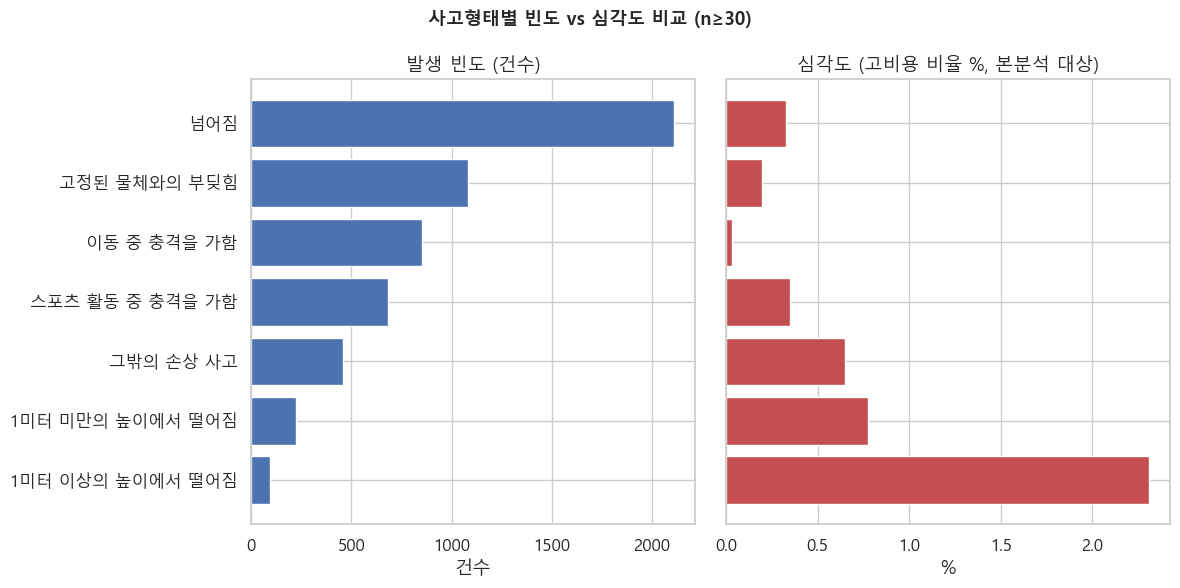

In [31]:
# 빈도 vs 심각도 비교 그래프
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

top_freq_types = fs_main.nlargest(5, '사고건수')['사고형태'].tolist()
top_severity_types = fs_main.nlargest(5, '심각도(%)')['사고형태'].tolist()
compare_types = list(dict.fromkeys(top_freq_types + top_severity_types))

plot_data = (
    fs_main[fs_main['사고형태'].isin(compare_types)]
    .sort_values('사고건수', ascending=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

ax1.barh(plot_data['사고형태'], plot_data['사고건수'], color='#4C72B0')
ax1.set_title('발생 빈도 (건수)')
ax1.set_xlabel('건수')

ax2.barh(plot_data['사고형태'], plot_data['심각도(%)'], color='#C44E52')
ax2.set_title('심각도 (고비용 비율 %, 본분석 대상)')
ax2.set_xlabel('%')

plt.suptitle('사고형태별 빈도 vs 심각도 비교 (n≥30)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

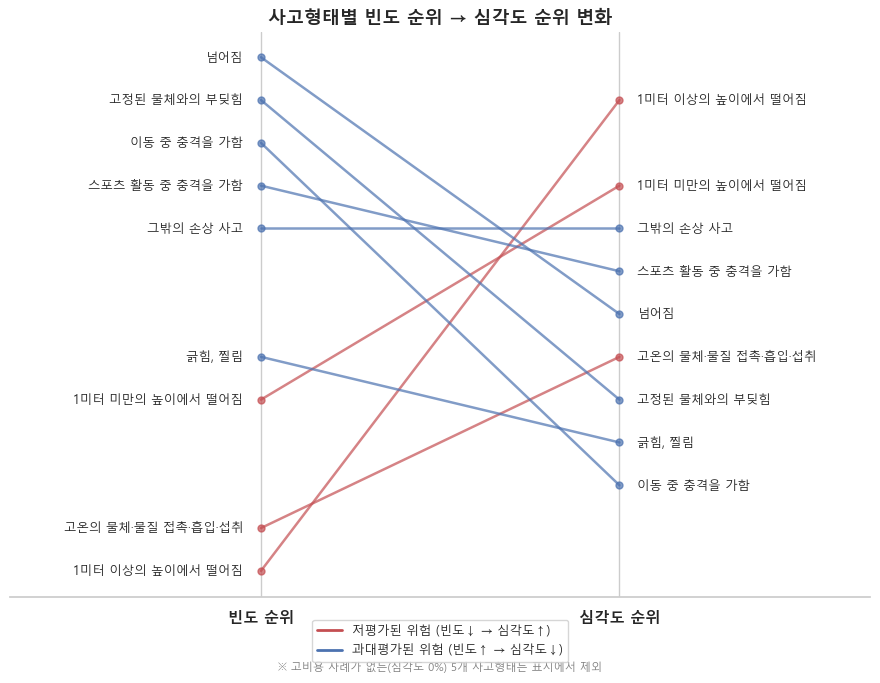

In [32]:
# 사고형태별 순위 변화 그래프
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 심각도가 0%보다 큰(=실제로 고비용 사례가 1건이라도 있는) 유형만 슬로프 대상으로 삼음
# 심각도 0%인 유형은 "차이가 없다"는 정보밖에 없어서 개별 표시 실익이 낮음
fs_nonzero = fs_main[fs_main['심각도(%)'] > 0].copy()

# 저평가(빈도↓ 심각도↑) / 과대평가(빈도↑ 심각도↓) 각각 상위 6개씩만
top_underrated = fs_nonzero.nlargest(6, '순위차이')
top_overrated = fs_nonzero.nsmallest(6, '순위차이')

slope_data = pd.concat([top_underrated, top_overrated]).drop_duplicates(subset='사고형태')

# 제외된(심각도 0%) 유형 개수는 그래프 하단에 안내 문구로 표시
excluded_count = len(fs_main) - len(fs_nonzero)

fig, ax = plt.subplots(figsize=(9, 7))

for _, row in slope_data.iterrows():
    color = '#C44E52' if row['순위차이'] > 0 else '#4C72B0'
    ax.plot([0, 1], [row['빈도순위'], row['심각도순위']], color=color, alpha=0.7, linewidth=1.8, marker='o', markersize=5)
    ax.text(-0.05, row['빈도순위'], row['사고형태'], ha='right', va='center', fontsize=9)
    ax.text(1.05, row['심각도순위'], row['사고형태'], ha='left', va='center', fontsize=9)

ax.set_xlim(-0.7, 1.7)
ax.invert_yaxis()
ax.set_xticks([0, 1])
ax.set_xticklabels(['빈도 순위', '심각도 순위'], fontsize=11, fontweight='bold')
ax.set_yticks([])
ax.set_title('사고형태별 빈도 순위 → 심각도 순위 변화', fontsize=13, fontweight='bold')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#C44E52', lw=2, label='저평가된 위험 (빈도↓ → 심각도↑)'),
    Line2D([0], [0], color='#4C72B0', lw=2, label='과대평가된 위험 (빈도↑ → 심각도↓)')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.03), ncol=1, fontsize=9)

# 제외 안내 문구
if excluded_count > 0:
    ax.text(0.5, -0.13, f'※ 고비용 사례가 없는(심각도 0%) {excluded_count}개 사고형태는 표시에서 제외',
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

### **본 분석 데이터 EDA & 전처리**

- 사고시간 = '현장학습', '수련활동, 수학여행'
- 연도 = 2021, 2022, 2023, 2024, 2025

#### 사고시간 필터링

In [33]:
# 사고시간 기준 필터링
trip_labels = ['현장학습', '수련활동, 수학여행']

acc_main = accident_df[accident_df['사고시간'].isin(trip_labels)].copy()
comp_main = compensation_df[compensation_df['사고시간'].isin(trip_labels)].copy()

print(f"사고 데이터 (본문 분석용, 2021~2025): {len(acc_main):,}건")
print(f"보상 데이터 (본문 분석용, 2021~2025): {len(comp_main):,}건")

사고 데이터 (본문 분석용, 2021~2025): 10,142건
보상 데이터 (본문 분석용, 2021~2025): 6,761건


#### 컬럼 생성 및 삭제

In [34]:
# '총보상금' 컬럼 생성
HARM_COLUMNS = ['요양급여', '장해급여', '간병급여', '유족급여', '장례비']

comp_main['총보상금'] = comp_main[HARM_COLUMNS].sum(axis=1)

In [35]:
# 불필요한 컬럼 삭제
acc_main = acc_main.drop(columns=['구분', '실제사고연도'])
comp_main = comp_main.drop(columns=['구분', '위로금', '보전비용'])

print("acc_main 컬럼:", acc_main.columns.tolist())
print("comp_main 컬럼:", comp_main.columns.tolist())

acc_main 컬럼: ['지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고연월', '사고발생시각', '사고요일', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '접수연도', '사고연월_파싱', '사고연도']
comp_main 컬럼: ['지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '요양급여', '장해급여', '간병급여', '유족급여', '장례비', '지급연도', '총보상금']


#### 연도

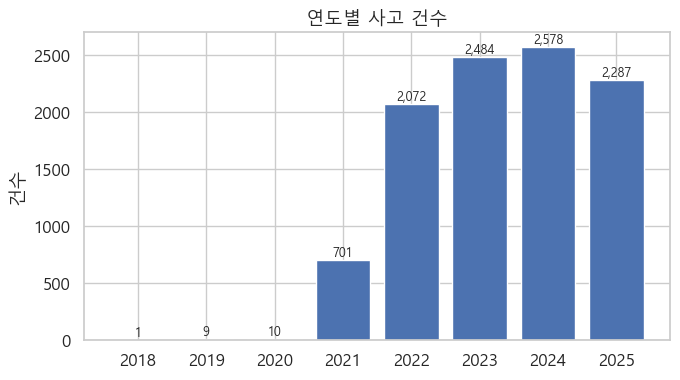

In [36]:
year_counts = acc_main['사고연도'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(year_counts.index.astype(str), year_counts.values, color='#4C72B0')
ax.set_title('연도별 사고 건수')
ax.set_ylabel('건수')

for i, v in enumerate(year_counts.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 사고시간 - 현장학습 vs 수련활동·수학여행

- 현장학습 66% vs 수련활동·수학여행 34%

In [37]:
trip_type_counts = acc_main['사고시간'].value_counts()
trip_type_pct = (trip_type_counts / trip_type_counts.sum() * 100).round(1)

trip_type_table = pd.DataFrame({
    '건수': trip_type_counts,
    '비율(%)': trip_type_pct
})

display(trip_type_table)

,건수,비율(%)
사고시간,,
현장학습,6732,66.4
"수련활동, 수학여행",3410,33.6


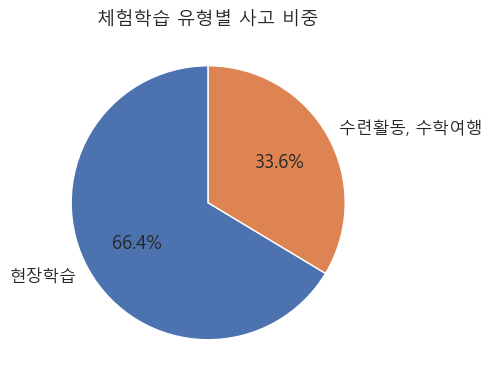

In [38]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(trip_type_counts, labels=trip_type_counts.index, autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('체험학습 유형별 사고 비중')
plt.tight_layout()
plt.show()

#### 학교급

- 초등학교 > 중학교 > 고등학교 순

학교급
초등학교    3525
중학교     2900
고등학교    2503
유치원     1061
특수학교      79
기타학교      74
Name: count, dtype: int64


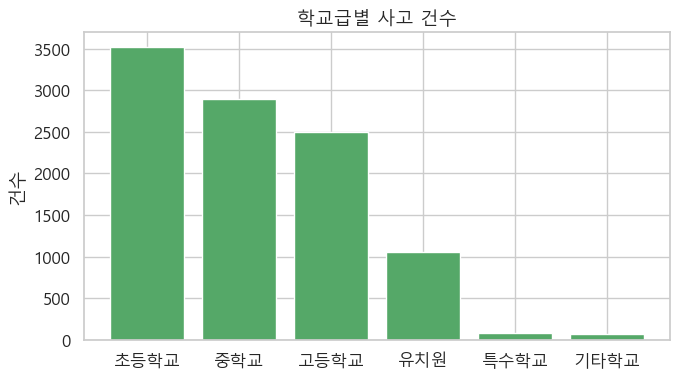

In [39]:
school_level_counts = acc_main['학교급'].value_counts()
print(school_level_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(school_level_counts.index, school_level_counts.values, color='#55A868')
ax.set_title('학교급별 사고 건수')
ax.set_ylabel('건수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 사고장소·사고당시활동

- **사고장소**: 기타 교외 > 청소년 수련 시설 > 실·내외 체육시설
- **사고당시활동**: 걷기/뛰기, 오르내리기 > 기타 > 장난, 놀이

In [40]:
print("사고장소 상위 15개")
print(acc_main['사고장소'].value_counts().head(15))

사고장소 상위 15개
사고장소
기타 교외             2752
청소년 수련 시설         1448
실·내외 체육시설          951
공원, 유원 시설          900
전시관, 체험관           697
어린이 놀이시설           609
숙박시설/식당            532
기타 문화·체육공간         489
산림·계곡              314
문화유적지              221
운동장                134
기타 자연              134
강·바다·하천            121
교통구역(스쿨존 외)-인도     114
교통구역(스쿨존 내)-인도     102
Name: count, dtype: int64


In [41]:
print("사고당시활동 상위 15개")
print(acc_main['사고당시활동'].value_counts().head(15))

사고당시활동 상위 15개
사고당시활동
걷기/뛰기, 오르내리기             2755
기타                       1508
장난, 놀이                   1075
스케이트                      750
휴식                        700
기타 스포츠 활동                 671
(교통수단 등) 운전, 조작, 탑승 중     425
기타 일상활동                   277
수업                        187
일반실습                      149
축구                        138
식사                        136
기타 바퀴달린 무동력 스포츠           134
인라인/롤러 스케이트               122
수영                        120
Name: count, dtype: int64


#### 총보상금

- 총보상금 0원인 7건 확인 결과, 모두 보전비용만 지급 -> 삭제

In [42]:
print("총보상금이 0원인 건수:", (comp_main['총보상금'] == 0).sum())
print("총보상금이 음수인 건수:", (comp_main['총보상금'] < 0).sum())

총보상금이 0원인 건수: 7
총보상금이 음수인 건수: 0


In [43]:
# 총보상금이 0원인 건들의 인덱스 확인
zero_cases = comp_main[comp_main['총보상금'] == 0]
print("총보상금 0원 건수:", len(zero_cases))

# 원본 compensation_df에서 같은 인덱스의 위로금·보전비용·5개 항목 원값 확인
zero_case_detail = compensation_df.loc[
    zero_cases.index,
    ['요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용']
]
print(zero_case_detail)

총보상금 0원 건수: 7
        요양급여  장해급여  간병급여  유족급여  장례비  위로금      보전비용
30682      0     0     0     0    0    0     20000
30683      0     0     0     0    0    0     32000
135726     0     0     0     0    0    0   1630000
137654     0     0     0     0    0    0    817000
153737     0     0     0     0    0    0    158000
176354     0     0     0     0    0    0      7000
385415     0     0     0     0    0    0  20900000


In [44]:
# 보전비용만 지급되어 총보상금이 0원인 7건 삭제
zero_cases = comp_main[comp_main['총보상금'] == 0]
print(f"삭제 대상: {len(zero_cases)}건")

comp_main = comp_main[comp_main['총보상금'] > 0].reset_index(drop=True)
print(f"삭제 후 comp_main: {len(comp_main):,}건")

삭제 대상: 7건
삭제 후 comp_main: 6,754건


In [45]:
print(comp_main['총보상금'].describe())

count    6.754000e+03
mean     8.271660e+05
std      1.373343e+07
min      1.000000e+03
25%      5.700000e+04
50%      1.150000e+05
75%      2.860000e+05
max      5.972640e+08
Name: 총보상금, dtype: float64


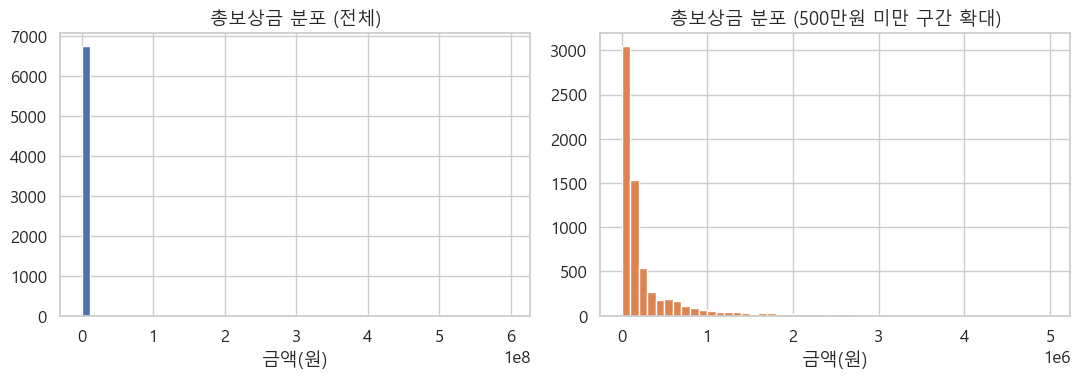

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(comp_main['총보상금'], bins=50, color='#4C72B0')
ax[0].set_title('총보상금 분포 (전체)')
ax[0].set_xlabel('금액(원)')

# 500만원 미만만 확대해서 보기 (극단값 때문에 전체 분포가 안 보이는 문제 보완)
under_5m = comp_main[comp_main['총보상금'] < 5_000_000]
ax[1].hist(under_5m['총보상금'], bins=50, color='#DD8452')
ax[1].set_title('총보상금 분포 (500만원 미만 구간 확대)')
ax[1].set_xlabel('금액(원)')

plt.tight_layout()
plt.show()

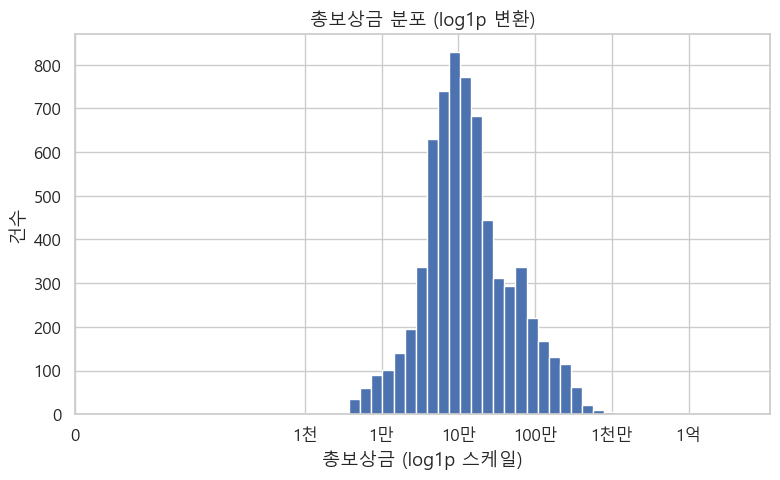

In [47]:
comp_main['총보상금_log1p'] = np.log1p(comp_main['총보상금'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comp_main['총보상금_log1p'], bins=40, color='#4C72B0', edgecolor='white')
ax.set_xlabel('총보상금 (log1p 스케일)')
ax.set_ylabel('건수')
ax.set_title('총보상금 분포 (log1p 변환)')

# x축을 실제 금액으로 읽기 쉽게 눈금 표시
tick_values = [0, 1000, 10000, 100000, 1000000, 10000000, 100000000]
ax.set_xticks(np.log1p(tick_values))
ax.set_xticklabels(['0', '1천', '1만', '10만', '100만', '1천만', '1억'])

plt.tight_layout()
plt.show()

In [48]:
comp_main['사망여부'] = (comp_main['유족급여'] > 0) | (comp_main['장례비'] > 0)
comp_main['장해여부'] = comp_main['장해급여'] > 0
comp_main['간병여부'] = comp_main['간병급여'] > 0
comp_main['요양만여부'] = (
    ~comp_main['사망여부'] & ~comp_main['장해여부'] & ~comp_main['간병여부']
)

print("각 급여 유형 지급 건수 (중복 가능)")
print(f"사망(유족급여/장례비): {comp_main['사망여부'].sum()}건")
print(f"장해급여: {comp_main['장해여부'].sum()}건")
print(f"간병급여: {comp_main['간병여부'].sum()}건")
print(f"요양급여만 발생: {comp_main['요양만여부'].sum()}건")

각 급여 유형 지급 건수 (중복 가능)
사망(유족급여/장례비): 5건
장해급여: 9건
간병급여: 2건
요양급여만 발생: 6738건


In [49]:
# 여러 급여가 동시에 발생하는 경우가 있는지 확인 (우선순위 규칙 필요 여부 판단)
overlap_check = comp_main[['사망여부', '장해여부', '간병여부']].sum(axis=1)
print("한 사고에 급여 유형이 2개 이상 겹치는 건수:", (overlap_check >= 2).sum())

한 사고에 급여 유형이 2개 이상 겹치는 건수: 0


#### 연도 X 총보상금

- 중앙값 5년 내내 일정 → 사건 하나하나의 전형적인 심각도 변화 X
- 위쪽 극단값 2023년부터 증가
- 박스 크기 일정 → 사고들의 편차가 커진게 아니라, 극단값만 증가

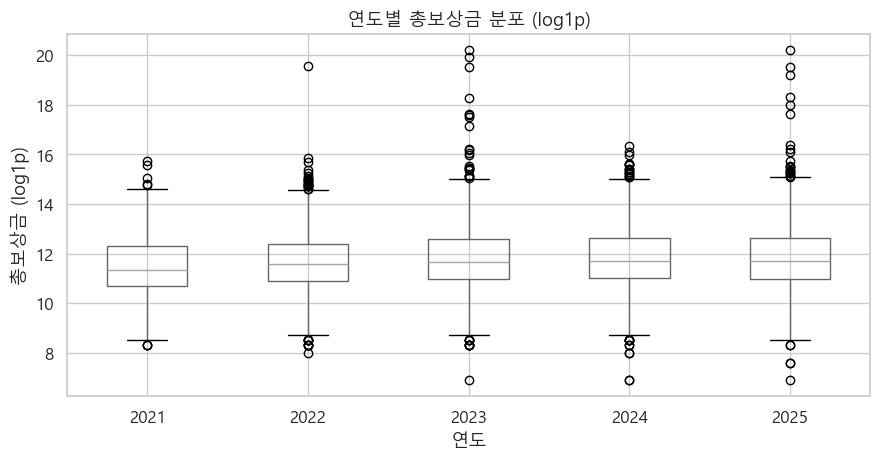

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
comp_main.boxplot(column='총보상금_log1p', by='지급연도', ax=ax)
ax.set_title('연도별 총보상금 분포 (log1p)')
ax.set_xlabel('연도')
ax.set_ylabel('총보상금 (log1p)')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### 사고시간 X 고비용 비율

- 수련활동·수학여행(0.975%) vs 현장학습(0.434%)
- 수련활동·수학여행이 현장학습의 약 2.24배

In [51]:
comp_main['고비용여부'] = comp_main['총보상금'] >= 5_000_000

type_severity = comp_main.groupby('사고시간')['고비용여부'].agg(
    전체건수='count', 고비용건수='sum'
).reset_index()
type_severity['고비용비율(%)'] = (type_severity['고비용건수'] / type_severity['전체건수'] * 100).round(3)

display(type_severity)

,사고시간,전체건수,고비용건수,고비용비율(%)
0,"수련활동, 수학여행",2154,21,0.975
1,현장학습,4600,20,0.435


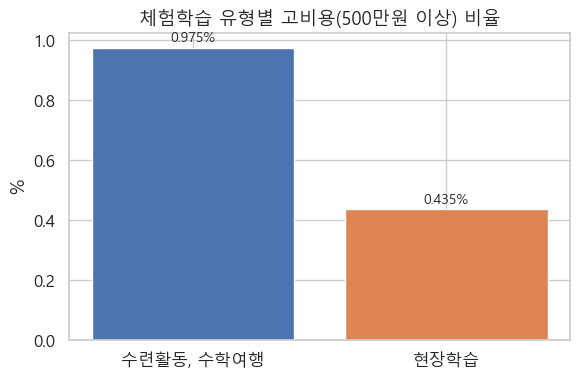

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(type_severity['사고시간'], type_severity['고비용비율(%)'], color=['#4C72B0', '#DD8452'])
ax.set_title('체험학습 유형별 고비용(500만원 이상) 비율')
ax.set_ylabel('%')

for i, v in enumerate(type_severity['고비용비율(%)']):
    ax.text(i, v + 0.02, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### 학교급 X 고비용 비율

- 특수학교가 고비용비율이 약 2%로 가장 높으나, 건수가 적어 과대해석 가능성
- 고등학교가 약 1.5%로 다음으로 높고, 건수 충분함

In [53]:
school_severity = comp_main.groupby('학교급')['고비용여부'].agg(
    전체건수='count', 고비용건수='sum'
).reset_index()
school_severity['고비용비율(%)'] = (school_severity['고비용건수'] / school_severity['전체건수'] * 100).round(3)

display(school_severity.sort_values('고비용비율(%)', ascending=False))

,학교급,전체건수,고비용건수,고비용비율(%)
5,특수학교,48,1,2.083
0,고등학교,1662,25,1.504
3,중학교,1852,8,0.432
4,초등학교,2308,7,0.303
1,기타학교,49,0,0.000
2,유치원,835,0,0.000


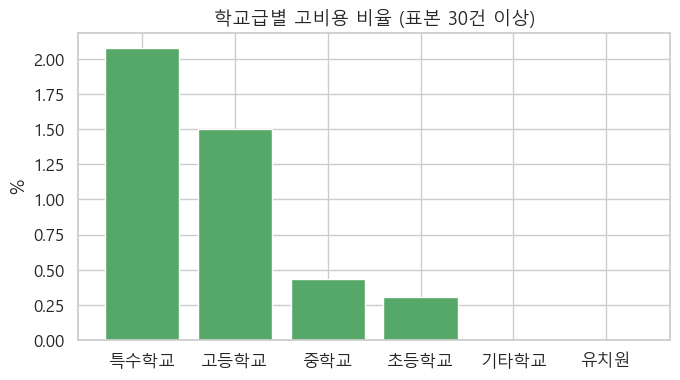

In [54]:
plot_data = school_severity[school_severity['전체건수'] >= 30].sort_values('고비용비율(%)', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(plot_data['학교급'], plot_data['고비용비율(%)'], color='#55A868')
ax.set_title('학교급별 고비용 비율 (표본 30건 이상)')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

In [55]:
# Wilson 보정
from statsmodels.stats.proportion import proportion_confint

school_severity = comp_main.groupby('학교급')['고비용여부'].agg(
    전체건수='count', 고비용건수='sum'
).reset_index()

ci_lower, ci_upper = proportion_confint(
    count=school_severity['고비용건수'],
    nobs=school_severity['전체건수'],
    method='wilson'
)
school_severity['하한(%)'] = (ci_lower * 100).round(3)
school_severity['상한(%)'] = (ci_upper * 100).round(3)
school_severity['고비용비율(%)'] = (school_severity['고비용건수'] / school_severity['전체건수'] * 100).round(3)

display(school_severity.sort_values('고비용비율(%)', ascending=False)[
    ['학교급', '전체건수', '고비용건수', '고비용비율(%)', '하한(%)', '상한(%)']
])

,학교급,전체건수,고비용건수,고비용비율(%),하한(%),상한(%)
5,특수학교,48,1,2.083,0.369,10.899
0,고등학교,1662,25,1.504,1.021,2.211
3,중학교,1852,8,0.432,0.219,0.850
4,초등학교,2308,7,0.303,0.147,0.625
1,기타학교,49,0,0.000,0.000,7.270
2,유치원,835,0,0.000,0.000,0.458


#### 사고장소 × 사고형태

- 기타 교외 × 넘어짐 (509건)
- 실·내외 체육시설 × 움직이는 물체와의 부딪힘 (226건)
- 청소년 수련시설 × 넘어짐 (338건)

In [56]:
top_places = acc_main['사고장소'].value_counts().head(8).index
top_types = acc_main['사고형태'].value_counts().head(8).index

subset = acc_main[acc_main['사고장소'].isin(top_places) & acc_main['사고형태'].isin(top_types)]
cross_table = pd.crosstab(subset['사고장소'], subset['사고형태'])

display(cross_table)

사고형태,1미터 미만의 높이에서 떨어짐,고정된 물체와의 부딪힘,그밖의 손상 사고,넘어짐,사람과의 부딪힘,스포츠 활동 중 충격을 가함,움직이는 물체와의 부딪힘,이동 중 충격을 가함
사고장소,,,,,,,,
"공원, 유원 시설",37,123,48,317,40,39,59,110
기타 교외,137,509,240,1412,51,22,16,51
기타 문화·체육공간,8,84,31,141,26,58,34,44
숙박시설/식당,24,119,50,93,28,12,25,54
실·내외 체육시설,11,110,13,413,58,226,52,23
어린이 놀이시설,48,111,51,133,40,72,16,70
"전시관, 체험관",26,150,28,171,47,33,41,84
청소년 수련 시설,40,209,108,338,117,174,92,131


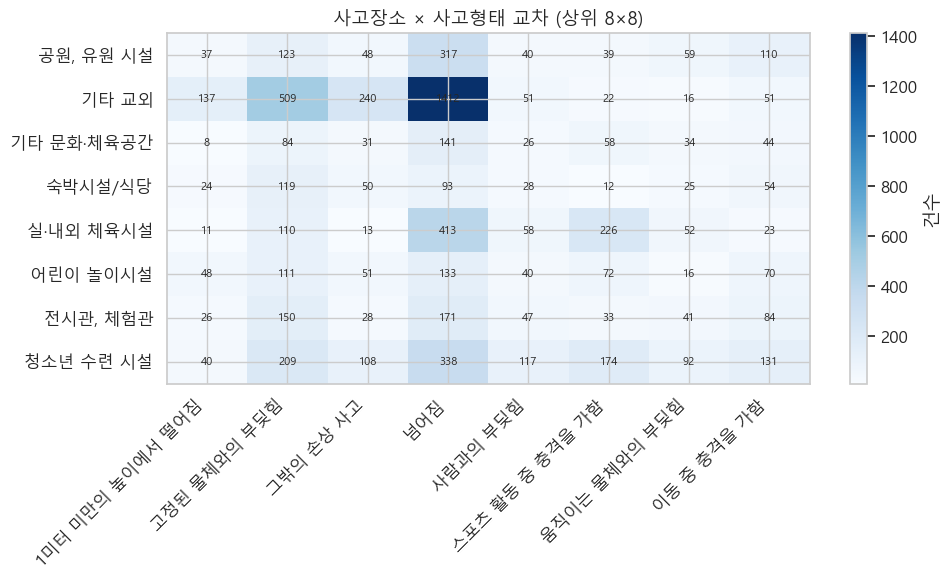

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(cross_table.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(cross_table.columns)))
ax.set_xticklabels(cross_table.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cross_table.index)))
ax.set_yticklabels(cross_table.index)
ax.set_title('사고장소 × 사고형태 교차 (상위 8×8)')

for i in range(len(cross_table.index)):
    for j in range(len(cross_table.columns)):
        ax.text(j, i, cross_table.values[i, j], ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='건수')
plt.tight_layout()
plt.show()

#### 전처리 데이터 저장하기 

In [58]:
# EDA용으로 임시 생성했던 파생 컬럼 정리
comp_main = comp_main.drop(columns=['총보상금_log1p', '고비용여부', '사망여부', '장해여부', '간병여부', '요양만여부'], errors='ignore')

print("acc_main 최종 컬럼:", acc_main.columns.tolist())
print("comp_main 최종 컬럼:", comp_main.columns.tolist())

acc_main 최종 컬럼: ['지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고연월', '사고발생시각', '사고요일', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '접수연도', '사고연월_파싱', '사고연도']
comp_main 최종 컬럼: ['지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '요양급여', '장해급여', '간병급여', '유족급여', '장례비', '지급연도', '총보상금']


In [59]:
# 최종 저장
acc_main.to_csv(PROCESSED_DIR /'acc_main_preprocessed.csv', index=False, encoding='utf-8-sig')
comp_main.to_csv(PROCESSED_DIR /'comp_main_preprocessed.csv', index=False, encoding='utf-8-sig')

print("저장 완료")
print(f"acc_main: {acc_main.shape}")
print(f"comp_main: {comp_main.shape}")

저장 완료
acc_main: (10142, 16)
comp_main: (6754, 17)
